In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### Project Objective

The goal of this analysis is to understand customer behavior in a city-specific market and build a restaurant recommendation system that matches user profiles with Yelp restaurant data.

**Dataset:** 2,547 client records from Boston with demographic, behavioral, and preference data. Yelp API used to collect 200+ restaurants with ratings, price levels, categories, and review counts.


## A. Exploratory Analysis, Data Cleaning and Preprocessing

**Export CSV file**

In [2]:
archivo = "base_datos_restaurantes_USA_v2.csv"
df = pd.read_csv(archivo)
df.head()

,id_persona,nombre,apellido,edad,genero,ciudad_residencia,estrato_socioeconomico,frecuencia_visita,promedio_gasto_comida,ocio,consume_licor,preferencias_alimenticias,membresia_premium,telefono_contacto,correo_electronico,tipo_de_pago_mas_usado,ingresos_mensuales
0,2550327378,Jackson,Gomez,31.0,Masculino,Miami,Alto,6,67.51,Sí,No,Vegetariano,Sí,(830)220-1926,NaN,Efectivo,6425
1,9446112038,Samantha,Soto,40.0,Femenino,Denver,Medio,2,44.92,Sí,Sí,Mariscos,No,881-476-1426,NaN,Efectivo,2374
2,3098363243,Terry,Adams,62.0,Femenino,Denver,Bajo,2,9.24,Sí,Sí,Vegetariano,No,NaN,diana74@example.net,Efectivo,1110
3,4013002847,James,Shannon,41.0,Masculino,Boston,Alto,5,30.74,Sí,Sí,Carnes,Sí,NaN,scottfrey@example.com,Tarjeta,6931
4,7372911048,Susan,Jones,49.0,Femenino,San Diego,Bajo,0,0.00,No,No,Carnes,No,243.248.8919,glassgary@example.org,Tarjeta,1350


##### City Selection

Boston was selected as the analysis city to maintain consistency between the client database and Yelp restaurant data. The Yelp API was queried with Boston coordinates and a 10km radius.


In [3]:
df_limpio= df[df["ciudad_residencia"] == "Boston"].copy()

df_limpio.head()


,id_persona,nombre,apellido,edad,genero,ciudad_residencia,estrato_socioeconomico,frecuencia_visita,promedio_gasto_comida,ocio,consume_licor,preferencias_alimenticias,membresia_premium,telefono_contacto,correo_electronico,tipo_de_pago_mas_usado,ingresos_mensuales
3,4013002847,James,Shannon,41.0,Masculino,Boston,Alto,5,30.74,Sí,Sí,Carnes,Sí,NaN,scottfrey@example.com,Tarjeta,6931
7,8373803828,Julie,Russo,66.0,Femenino,Boston,Muy Alto,9,19.94,No,Sí,Vegetariano,Sí,NaN,NaN,Efectivo,13456
9,5394273061,Sara,Ball,37.0,Femenino,Boston,Bajo,1,11.35,Sí,No,Carnes,No,563-346-4749x6591,smithstacy@example.com,Efectivo,1197
19,9336353877,Mary,Bentley,29.0,Femenino,Boston,Medio,2,11.22,No,Sí,Vegetariano,No,6382528579,NaN,Efectivo,2052
26,1232293617,Elizabeth,Griffin,51.0,Femenino,Boston,Alto,6,51.46,No,No,Vegetariano,Sí,906.282.9481,NaN,Efectivo,8499


#### 1. Database Exploration — Understanding Data Structure

In [4]:
df_limpio.shape

(2547, 17)

- The dataset filtered for Boston contains **2,547 rows and 17 columns**

Column names and data types are shown below:

In [5]:
df_limpio.columns

Index(['id_persona', 'nombre', 'apellido', 'edad', 'genero',
       'ciudad_residencia', 'estrato_socioeconomico', 'frecuencia_visita',
       'promedio_gasto_comida', 'ocio', 'consume_licor',
       'preferencias_alimenticias', 'membresia_premium', 'telefono_contacto',
       'correo_electronico', 'tipo_de_pago_mas_usado', 'ingresos_mensuales'],
      dtype='str')

Below we examine Non-Null counts and data types for each variable:

In [6]:
df_limpio.info()

<class 'pandas.DataFrame'>
Index: 2547 entries, 3 to 29976
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_persona                 2547 non-null   int64  
 1   nombre                     2547 non-null   str    
 2   apellido                   2547 non-null   str    
 3   edad                       2537 non-null   float64
 4   genero                     2547 non-null   str    
 5   ciudad_residencia          2547 non-null   str    
 6   estrato_socioeconomico     2547 non-null   str    
 7   frecuencia_visita          2547 non-null   int64  
 8   promedio_gasto_comida      2541 non-null   float64
 9   ocio                       2547 non-null   str    
 10  consume_licor              2547 non-null   str    
 11  preferencias_alimenticias  2445 non-null   str    
 12  membresia_premium          2547 non-null   str    
 13  telefono_contacto          1283 non-null   str    
 14  correo_

In the 2,547 Boston records, the columns `age`, `avg_food_spending`, `dietary_preferences`, `visit_frequency`, `contact_phone`, and `email` have missing values that require treatment.

We extract summary statistics using `.describe()`

In [7]:
df_limpio.describe() #Obteniendo estadísticas descriptivas de las columnas numéricas del DataFrame copia, como la media, desviación estándar, valores mínimos y máximos, entre otros.

,id_persona,edad,frecuencia_visita,promedio_gasto_comida,ingresos_mensuales
count,2.547000e+03,2537.000000,2547.000000,2541.000000,2547.000000
mean,5.548750e+09,49.512810,3.980762,29.494766,5658.080487
std,2.620686e+09,23.670266,2.792514,23.960740,4725.407151
min,1.010508e+09,-5.000000,-3.000000,0.000000,807.000000
25%,3.234152e+09,33.000000,2.000000,11.340000,1852.500000
50%,5.642463e+09,49.000000,4.000000,22.790000,3657.000000
75%,7.760216e+09,65.000000,6.000000,41.170000,8237.000000
max,9.993177e+09,300.000000,10.000000,104.600000,17972.000000


Upon initial inspection of the dataset:

- The database contains demographic and behavioral information about restaurant customers in Boston
- Key variables: `age`, `gender`, `socioeconomic_status`, `visit_frequency`, `avg_food_spending`, `premium_membership`, `dietary_preferences`
- Missing values are present in several columns — a hierarchical imputation strategy will be applied
- No structural data quality issues (wrong data types, impossible formats)


### 2. Null Values and Duplicates Check

##### 2.1 Null Value Verification

In [8]:
df_limpio.isnull().sum().sort_values(ascending=False) #Contando el número de valores nulos en cada columna del DataFrame original y ordenándolos de mayor a menor para identificar las columnas con más valores faltantes.

correo_electronico           1276
telefono_contacto            1264
preferencias_alimenticias     102
edad                           10
promedio_gasto_comida           6
id_persona                      0
genero                          0
apellido                        0
nombre                          0
frecuencia_visita               0
estrato_socioeconomico          0
ciudad_residencia               0
ocio                            0
membresia_premium               0
consume_licor                   0
tipo_de_pago_mas_usado          0
ingresos_mensuales              0
dtype: int64

- Columns with most missing values: `contact_phone` and `email` (contact info — cannot be imputed statistically)
- Missing values also present in `dietary_preferences`, `age`, `visit_frequency`, and `avg_food_spending`
- Strategy: hierarchical imputation using correlated demographic variables


In [9]:
print('Los valores faltantes representan el siguiente porcentaje del total de filas en cada columna:')
((df_limpio.isnull().sum() / len(df_limpio)) * 100).sort_values(ascending=False)


Los valores faltantes representan el siguiente porcentaje del total de filas en cada columna:


correo_electronico           50.098155
telefono_contacto            49.627012
preferencias_alimenticias     4.004711
edad                          0.392619
promedio_gasto_comida         0.235571
id_persona                    0.000000
genero                        0.000000
apellido                      0.000000
nombre                        0.000000
frecuencia_visita             0.000000
estrato_socioeconomico        0.000000
ciudad_residencia             0.000000
ocio                          0.000000
membresia_premium             0.000000
consume_licor                 0.000000
tipo_de_pago_mas_usado        0.000000
ingresos_mensuales            0.000000
dtype: float64

##### 2.2 Duplicate Records Check

In [10]:
df_limpio.duplicated(subset=["id_persona"]).sum()

np.int64(0)

No duplicate entries found in the dataframe.

### 3. Data Treatment Decisions

Based on null value analysis and the nature of each variable, the following imputation strategy was defined:

- **`age`**: impute with median by gender and socioeconomic status group
- **`visit_frequency`**: impute using correlated variables (premium membership, socioeconomic status)
- **`avg_food_spending`**: impute using socioeconomic status and premium membership groups
- **`dietary_preferences`**: impute with mode of similar demographic groups
- **`contact_phone` / `email`**: fill with 'Not registered' — cannot be statistically imputed


#### 3.1 Identifying rows with invalid age values (negative or >100)

In [11]:
df_limpio[df_limpio["edad"] < 0]


,id_persona,nombre,apellido,edad,genero,ciudad_residencia,estrato_socioeconomico,frecuencia_visita,promedio_gasto_comida,ocio,consume_licor,preferencias_alimenticias,membresia_premium,telefono_contacto,correo_electronico,tipo_de_pago_mas_usado,ingresos_mensuales
2482,1737293582,Holly,Gallagher,-5.0,Femenino,Boston,Medio,4,22.82,Sí,No,Carnes,No,NaN,websteramanda@example.org,Efectivo,2836
6777,6826129434,Megan,Russell,-5.0,Femenino,Boston,Medio,3,7.20,No,Sí,Pescado,No,NaN,walkerwilliam@example.net,App,2330
14448,9852786935,Crystal,Jenkins,-5.0,Femenino,Boston,Muy Alto,10,69.67,No,Sí,Carnes,Sí,345.625.4596,NaN,Efectivo,12586
24330,3334126899,Beth,Nicholson,-5.0,Femenino,Boston,Alto,4,19.51,Sí,Sí,Vegetariano,Sí,3149433778,NaN,Efectivo,7730
26734,9433104084,Albert,Johnson,-5.0,Masculino,Boston,Alto,-3,11.55,No,No,Mariscos,Sí,NaN,NaN,Efectivo,4451


In [12]:
df_limpio[df_limpio["edad"] > 100]

,id_persona,nombre,apellido,edad,genero,ciudad_residencia,estrato_socioeconomico,frecuencia_visita,promedio_gasto_comida,ocio,consume_licor,preferencias_alimenticias,membresia_premium,telefono_contacto,correo_electronico,tipo_de_pago_mas_usado,ingresos_mensuales
2101,4640435053,Adam,Young,300.0,Masculino,Boston,Medio,4,14.13,No,Sí,Vegetariano,No,NaN,ryan08@example.com,App,2958
2529,6228635509,Jason,Matthews,300.0,Masculino,Boston,Muy Alto,10,85.96,No,No,Mariscos,Sí,(879)385-9416,kathyjones@example.com,Tarjeta,9729
4492,6448324230,Erik,Martinez,300.0,Masculino,Boston,Bajo,3,13.81,No,Sí,Carnes,No,NaN,NaN,Tarjeta,1364
6313,2539612479,Brian,Farrell,300.0,Masculino,Boston,Medio,3,32.56,No,Sí,Carnes,No,370-361-2950x83474,ymolina@example.com,Tarjeta,2892
9661,6934932642,Jonathan,Sims,300.0,Masculino,Boston,Alto,5,5.40,Sí,No,Otro,No,(611)682-4018x8904,jessica55@example.org,Tarjeta,8060
13785,9263135031,Amy,Matthews,300.0,Femenino,Boston,Alto,4,7.58,No,No,Carnes,No,NaN,NaN,App,4382
19943,1546416390,Caleb,Anderson,300.0,Masculino,Boston,Bajo,3,14.57,Sí,Sí,Carnes,No,NaN,NaN,App,1474
24022,3656689261,Anna,Blanchard,300.0,Femenino,Boston,Muy Alto,7,102.93,Sí,Sí,Otro,Sí,NaN,igarza@example.com,Efectivo,10230
28038,2092282503,Bryan,Pratt,300.0,Masculino,Boston,Muy Alto,8,22.44,No,No,Otro,Sí,701-452-1033,lindsay47@example.net,Efectivo,9582


#### 3.2 Identifying negative values in visit_frequency and avg_food_spending

In [13]:
df_limpio[df_limpio["frecuencia_visita"] < 0]

,id_persona,nombre,apellido,edad,genero,ciudad_residencia,estrato_socioeconomico,frecuencia_visita,promedio_gasto_comida,ocio,consume_licor,preferencias_alimenticias,membresia_premium,telefono_contacto,correo_electronico,tipo_de_pago_mas_usado,ingresos_mensuales
496,1420654268,Keith,Hensley,42.0,Masculino,Boston,Muy Alto,-3,104.17,Sí,Sí,Vegano,Sí,NaN,raymondbeasley@example.org,Efectivo,9806
602,9674596936,Lauren,Kelly,19.0,Femenino,Boston,Medio,-3,5.88,Sí,Sí,NaN,No,445.962.1555,eric16@example.net,App,2726
734,9190753627,Danielle,Abbott,27.0,Femenino,Boston,Medio,-3,13.69,No,Sí,Pescado,No,365-598-1157,cbass@example.net,Efectivo,2450
969,9872029928,Sarah,Miller,42.0,Femenino,Boston,Alto,-3,36.58,No,Sí,Vegetariano,No,NaN,kellystone@example.com,App,6940
1051,5853660504,Victor,Gibbs,68.0,Masculino,Boston,Bajo,-3,13.22,Sí,No,Pescado,No,001-586-421-7008x781,davisdaniel@example.org,Efectivo,1265
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29124,3937505620,Sarah,Collins,71.0,Femenino,Boston,Muy Alto,-3,89.25,Sí,No,Carnes,Sí,NaN,NaN,Tarjeta,10280
29247,4540608132,Michelle,Thompson,70.0,Femenino,Boston,Alto,-3,7.45,No,No,Vegetariano,Sí,+1-449-217-8781x98931,matthewthomas@example.org,Tarjeta,5923
29354,8914054579,Ellen,Foster,41.0,Femenino,Boston,Medio,-3,30.28,Sí,No,Carnes,Sí,NaN,NaN,Efectivo,2071
29750,6869865000,Sandra,Cisneros,37.0,Femenino,Boston,Alto,-3,20.93,Sí,No,Carnes,No,NaN,NaN,Tarjeta,6999


In [14]:
df_limpio[df_limpio["promedio_gasto_comida"] < 0] #Identificando filas con valores negativos en la columna "promedio_gasto_comida", lo cual no tiene sentido en el contexto de gastos, para evaluar si es necesario corregir o eliminar esos registros del análisis.

,id_persona,nombre,apellido,edad,genero,ciudad_residencia,estrato_socioeconomico,frecuencia_visita,promedio_gasto_comida,ocio,consume_licor,preferencias_alimenticias,membresia_premium,telefono_contacto,correo_electronico,tipo_de_pago_mas_usado,ingresos_mensuales


In [15]:
df_limpio[df_limpio["preferencias_alimenticias"].isnull()]

,id_persona,nombre,apellido,edad,genero,ciudad_residencia,estrato_socioeconomico,frecuencia_visita,promedio_gasto_comida,ocio,consume_licor,preferencias_alimenticias,membresia_premium,telefono_contacto,correo_electronico,tipo_de_pago_mas_usado,ingresos_mensuales
52,4899320322,John,Anderson,50.0,Masculino,Boston,Bajo,0,0.00,Sí,No,NaN,No,001-238-768-6123x5879,mendozajamie@example.net,Tarjeta,1547
534,2922036958,Craig,Smith,56.0,Masculino,Boston,Alto,5,23.18,No,Sí,NaN,Sí,NaN,NaN,Efectivo,3998
602,9674596936,Lauren,Kelly,19.0,Femenino,Boston,Medio,-3,5.88,Sí,Sí,NaN,No,445.962.1555,eric16@example.net,App,2726
614,6450686199,Eileen,Patel,27.0,Femenino,Boston,Medio,3,15.67,Sí,Sí,NaN,No,777-944-4156,jason75@example.net,App,3286
615,1524498170,Deborah,Pham,31.0,Femenino,Boston,Alto,5,29.88,Sí,No,NaN,Sí,(781)680-1295,logan35@example.org,Efectivo,6583
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28056,1706906069,Diana,Davis,73.0,Femenino,Boston,Muy Alto,6,20.96,No,Sí,NaN,Sí,+1-430-656-1194x19121,timothyflores@example.com,Efectivo,14932
28674,2187275431,Allison,Williams,76.0,Femenino,Boston,Alto,4,32.71,No,No,NaN,Sí,NaN,NaN,Tarjeta,5923
29568,2692504896,Keith,Waller,31.0,Masculino,Boston,Alto,5,16.14,No,Sí,NaN,No,(840)934-4692x61204,dbright@example.org,Efectivo,4371
29640,8897608780,Laura,Tucker,26.0,Femenino,Boston,Bajo,1,5.50,No,Sí,NaN,No,(470)644-8980,kwilson@example.net,Efectivo,952


### 4. Data Cleaning and Transformation

#### 4.1 Correcting errors first

In [16]:
df_limpio.loc[(df_limpio["edad"] < 0) | (df_limpio["edad"] > 100), "edad"] = np.nan #Reemplazando valores negativos y mayores a 100 en la columna "edad" por NaN, ya que esos valores no son válidos para la edad de una persona.
df_limpio.loc[df_limpio["frecuencia_visita"] < 0, "frecuencia_visita"] = np.nan #Reemplazando valores negativos en la columna "frecuencia_visita" por NaN, ya que no tiene sentido tener una frecuencia de visita negativa a un restaurante.

#### 4.2 Age imputation using gender and socioeconomic status groups

Missing values in the `age` column will be filled with the median age calculated for each gender × socioeconomic_status combination.

In [17]:
df_limpio["edad"] = df_limpio["edad"].fillna(
    df_limpio.groupby(["estrato_socioeconomico", "genero"])["edad"].transform("median")
)

df_limpio["edad"] = df_limpio["edad"].fillna(
    df_limpio.groupby(["estrato_socioeconomico"])["edad"].transform("median")
)

df_limpio["edad"] = df_limpio["edad"].fillna(df_limpio["edad"].median())

#### 4.3 Visit frequency imputation using correlated variables

In [18]:
# Imputamos a nivel mas especifico
df_limpio["frecuencia_visita"] = df_limpio["frecuencia_visita"].fillna(
    df_limpio.groupby(["membresia_premium", "ocio"])["frecuencia_visita"].transform("median")
)

# Fallback global
df_limpio["frecuencia_visita"] = df_limpio["frecuencia_visita"].fillna(df_limpio["frecuencia_visita"].median())


#### 4.4 Avg food spending imputation using socioeconomic status and premium membership

In [19]:
df_limpio["promedio_gasto_comida"] = df_limpio["promedio_gasto_comida"].fillna(
    df_limpio.groupby(
        ["estrato_socioeconomico", "membresia_premium"]
    )["promedio_gasto_comida"].transform("median")
)

df_limpio["promedio_gasto_comida"] = df_limpio["promedio_gasto_comida"].fillna(
    df_limpio.groupby(["estrato_socioeconomico"])["promedio_gasto_comida"].transform("median")
)

df_limpio["promedio_gasto_comida"] = df_limpio["promedio_gasto_comida"].fillna(
    df_limpio["promedio_gasto_comida"].median()
)


#### 4.5 Dietary preferences imputation using group mode

The `dietary_preferences` variable will be imputed with the mode of groups formed by gender, socioeconomic status, and premium membership.

In [20]:
# Creando una nueva columna "grupo_edad" que categoriza la edad en grupos utilizando la función pd.cut(), 
# con los siguientes rangos: 0-18, 19-30, 31-45, 46-60 y 61-100.

df_limpio["grupo_edad"] = pd.cut(
    df_limpio["edad"],
    bins=[0, 18, 30, 45, 60, 100],
    labels=["0-18", "19-30", "31-45", "46-60", "61-100"]
)

# Calculando la moda de la columna "preferencias_alimenticias" para cada combinación de "genero", 
# "estrato_socioeconomico" y "grupo_edad", y luego utilizando esa moda para llenar los valores faltantes 
# en la columna "preferencias_alimenticias" del DataFrame limpio.

moda_pref = df_limpio.groupby(
    ["genero", "estrato_socioeconomico", "grupo_edad"]
)["preferencias_alimenticias"].transform(
    lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan
)

df_limpio["preferencias_alimenticias"] = df_limpio["preferencias_alimenticias"].fillna(moda_pref)

# Si aún quedan valores faltantes en "preferencias_alimenticias" después de llenar con la moda por grupo,
# se puede llenar esos valores faltantes con la moda general de "preferencias_alimenticias" por "estrato_socioeconomico" 
# y "grupo_edad", sin considerar el género

moda_pref_2 = df_limpio.groupby(
    ["estrato_socioeconomico", "grupo_edad"]
)["preferencias_alimenticias"].transform(
    lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan
)

# Finalmente, si aún quedan valores faltantes en "preferencias_alimenticias" después de llenar con la moda por grupo sin considerar el género,
#  se puede llenar esos valores faltantes con la moda general de "preferencias_alimenticias" en todo el DataFrame.

df_limpio["preferencias_alimenticias"] = df_limpio["preferencias_alimenticias"].fillna(moda_pref_2)

df_limpio["preferencias_alimenticias"] = df_limpio["preferencias_alimenticias"].fillna(
    df_limpio["preferencias_alimenticias"].mode()[0]
)


#### 4.6 Contact Data

Contact fields (`phone`, `email`) cannot be statistically imputed — filled with 'Not registered' to maintain data integrity.

In [21]:
df_limpio["telefono_contacto"] = df_limpio["telefono_contacto"].fillna("No registrado")
df_limpio["correo_electronico"] = df_limpio["correo_electronico"].fillna("No registrado")

### 5. Final Validation

In [22]:
df_limpio.isnull().sum().sort_values(ascending=False)

id_persona                   0
nombre                       0
apellido                     0
edad                         0
genero                       0
ciudad_residencia            0
estrato_socioeconomico       0
frecuencia_visita            0
promedio_gasto_comida        0
ocio                         0
consume_licor                0
preferencias_alimenticias    0
membresia_premium            0
telefono_contacto            0
correo_electronico           0
tipo_de_pago_mas_usado       0
ingresos_mensuales           0
grupo_edad                   0
dtype: int64

After cleaning, missing values were handled with a hierarchical imputation strategy:
- Numeric variables: median by demographic groups
- Categorical variables: mode by related groups
- Contact fields: preserved as 'Not registered'

**Result:** 0 null values remaining. Dataset ready for exploratory analysis and recommendation system.


In [23]:
df_limpio.to_csv("base_datos_clientes_limpia_Boston.csv", index=False)


## B. Exploratory Data Analysis (EDA) and Visualizations

##### Business Questions

1. What type of client shows the highest food spending?
2. What variables influence visit frequency most?
3. Is there a relationship between premium membership and spending/frequency?
4. What are the most common dietary preferences by demographic group?
5. How does income level correlate with restaurant spending?


In [24]:
sns.set_theme(style="whitegrid")
color_morado = sns.color_palette("Purples")[4]
palette_morada = "Purples"
orden_estrato = ["Bajo", "Medio", "Alto", "Muy Alto"]

### 1. Age Distribution

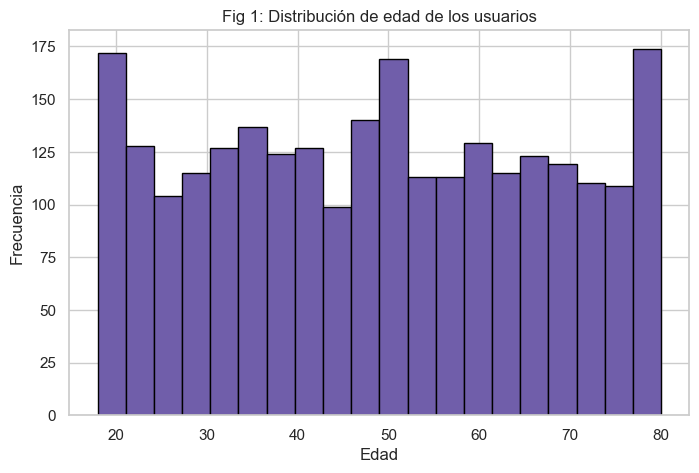

In [25]:
plt.figure(figsize=(8, 5))

plt.hist(
    df_limpio["edad"],
    bins=20,
    color=color_morado,
    edgecolor="black"
)

plt.title("Fig 1: Distribución de edad de los usuarios")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")

plt.show()

The age distribution of users is wide, with greater concentration in middle age ranges. This suggests the platform serves a diverse demographic — recommendation strategies should be age-aware.

### 2. Average Spending by Socioeconomic Status

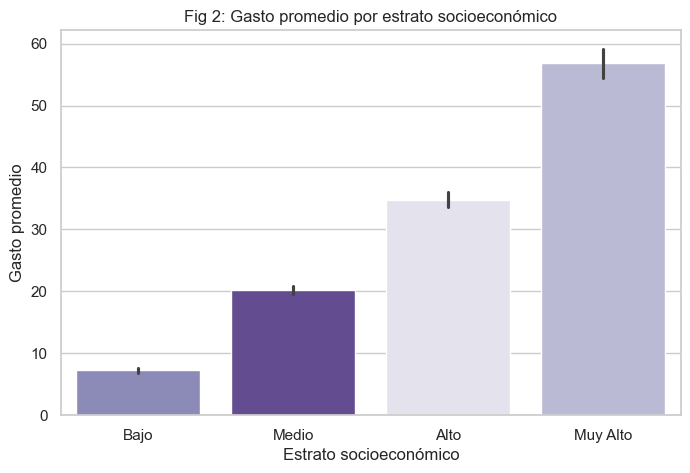

In [26]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x="estrato_socioeconomico",
    y="promedio_gasto_comida",
    data=df_limpio,
    hue="estrato_socioeconomico",
    palette="Purples",
    order=orden_estrato,
    legend=False
)

plt.title("Fig 2: Gasto promedio por estrato socioeconómico")
plt.xlabel("Estrato socioeconómico")
plt.ylabel("Gasto promedio")

plt.show()

plt.show()

A direct relationship is identified between socioeconomic status and average restaurant spending. Higher-status users tend to spend more per visit — a key variable for restaurant price-level matching in the recommendation system.

### 3. Visit Frequency vs Premium Membership

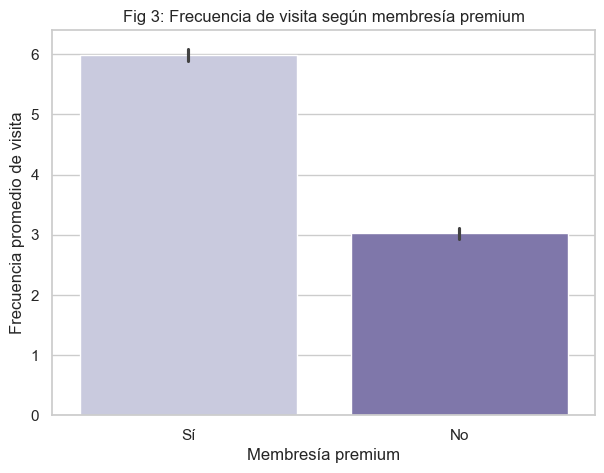

In [27]:
plt.figure(figsize=(7, 5))

sns.barplot(
    x="membresia_premium",
    y="frecuencia_visita",
    data=df_limpio,
    hue="membresia_premium",
    palette=palette_morada,
    estimator="mean",
    legend=False
)

plt.title("Fig 3: Frecuencia de visita según membresía premium")
plt.xlabel("Membresía premium")
plt.ylabel("Frecuencia promedio de visita")

plt.show()

Premium membership users show significantly higher visit frequency compared to non-members. This confirms that membership is a strong behavioral predictor and should carry high weight in the recommendation score.

### 4. Alcohol Consumption vs Average Spending

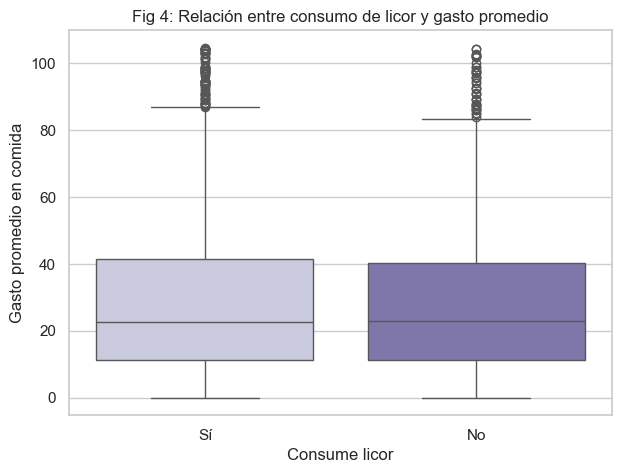

In [28]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    x="consume_licor",
    y="promedio_gasto_comida",
    data=df_limpio,
    hue="consume_licor",
    palette=palette_morada,
    legend=False
)

plt.title("Fig 4: Relación entre consumo de licor y gasto promedio")
plt.xlabel("Consume licor")
plt.ylabel("Gasto promedio en comida")

plt.show()

Users who consume alcohol tend to have higher average spending. This behavioral variable is used to match clients with restaurant types and price ranges in the recommendation engine.

### 5. Dietary Preferences Distribution

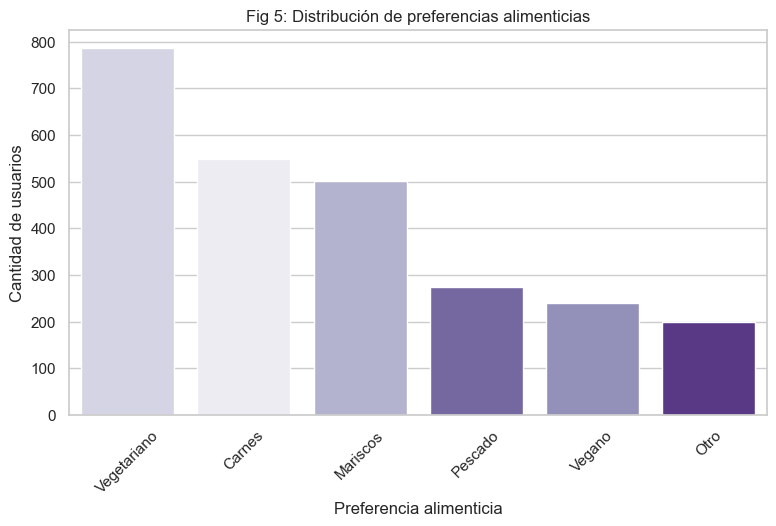

In [29]:
plt.figure(figsize=(9, 5))

sns.countplot(
    x="preferencias_alimenticias",
    data=df_limpio,
    hue="preferencias_alimenticias",
    palette=palette_morada,
    order=df_limpio["preferencias_alimenticias"].value_counts().index,
    legend=False
)

plt.title("Fig 5: Distribución de preferencias alimenticias")
plt.xlabel("Preferencia alimenticia")
plt.ylabel("Cantidad de usuarios")
plt.xticks(rotation=45)

plt.show()

The dietary preferences distribution shows significant diversity, with no single category dominating. This validates the need for a personalized recommendation approach rather than a one-size-fits-all solution.

### 6. Monthly Income vs Average Spending

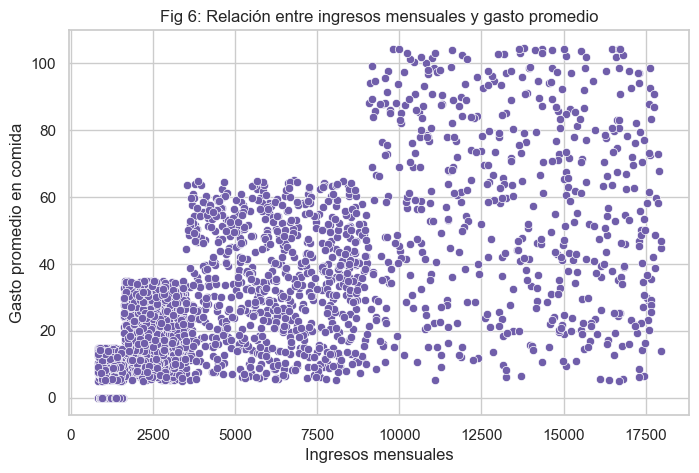

In [30]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    x="ingresos_mensuales",
    y="promedio_gasto_comida",
    data=df_limpio,
    color=color_morado
)

plt.title("Fig 6: Relación entre ingresos mensuales y gasto promedio")
plt.xlabel("Ingresos mensuales")
plt.ylabel("Gasto promedio en comida")

plt.show()

A positive trend exists between monthly income and average restaurant spending, with moderate dispersion. Income is used as a secondary variable in restaurant price-level matching.

### 7. Visit Frequency by Socioeconomic Status

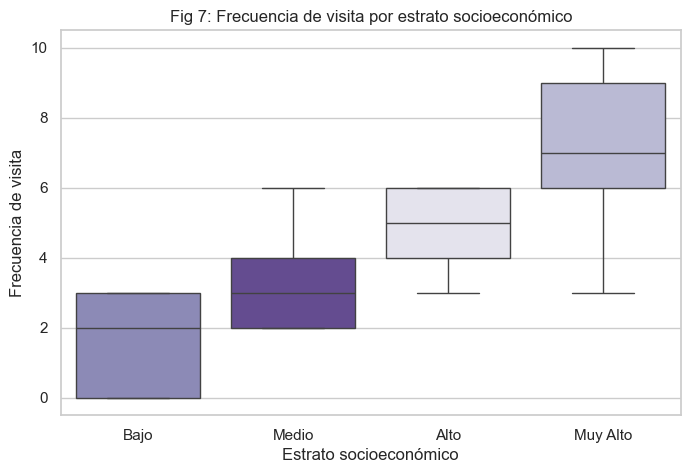

In [31]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="estrato_socioeconomico",
    y="frecuencia_visita",
    data=df_limpio,
    hue="estrato_socioeconomico",
    order=orden_estrato,
    palette=palette_morada,
    legend=False
)

plt.title("Fig 7: Frecuencia de visita por estrato socioeconómico")
plt.xlabel("Estrato socioeconómico")
plt.ylabel("Frecuencia de visita")

plt.show()

A growing trend in visit frequency is observed as socioeconomic status increases. Higher-status users are more frequent restaurant-goers and represent the most valuable segment for the recommendation platform.

## C. Recommendation System

#### Recommendation System Design

A recommendation system was developed that combines client information with restaurant characteristics from the Yelp API.

**Architecture:**
- **Client profile**: demographic variables, spending behavior, dietary preferences, visit frequency, premium membership
- **Restaurant data**: Yelp categories, ratings, review count, price level, location
- **Matching engine**: weighted score combining client preferences with restaurant attributes
- **Output**: ranked list of restaurants personalized for each user profile


In [32]:
import pandas as pd
import numpy as np

# Cargar datasets
clientes = pd.read_csv("base_datos_clientes_limpia_Boston.csv")
restaurantes = pd.read_csv("yelp_tratado_recomendador_escala_1_4.csv")

In [33]:
def convertir_a_lista(valor):
    if pd.isna(valor):
        return []
    return [item.strip() for item in str(valor).split(";")]

In [34]:
restaurantes["preferencias_compatibles"] = restaurantes["preferencias_compatibles"].apply(convertir_a_lista)
restaurantes["estratos_compatibles"] = restaurantes["estratos_compatibles"].apply(convertir_a_lista)

#### 3.5 Price Scale and Spending Alignment

The Yelp price variable originally comes as symbols: $, $$, $$$, $$$$. These were mapped to a numeric scale (1-4) aligned with the client's `avg_food_spending` quartiles for price-level matching.


In [35]:
def asignar_nivel_gasto(gasto):
    if gasto <= 15:
        return 1
    elif gasto <= 30:
        return 2
    elif gasto <= 60:
        return 3
    else:
        return 4

clientes["nivel_gasto"] = clientes["promedio_gasto_comida"].apply(asignar_nivel_gasto)

#### Total Score Calculation (score_total)

The total score (`recommendation_score`) is calculated as a weighted combination of:
- **Yelp rating** (weight: 0.40) — social validation and restaurant quality
- **Review count** (weight: 0.25) — popularity and reliability
- **Price match score** (weight: 0.20) — alignment between client spending and restaurant price level
- **Category match score** (weight: 0.15) — dietary preference compatibility


In [36]:
def recomendar_restaurantes(id_persona, df_usuarios, df_restaurantes, top_n=5):

    usuario = df_usuarios[df_usuarios["id_persona"] == id_persona]

    if usuario.empty:
        return "No se encontró un usuario con ese id_persona."

    usuario = usuario.iloc[0]
    recomendaciones = df_restaurantes.copy()

    recomendaciones["match_preferencia"] = recomendaciones["preferencias_compatibles"].apply(
        lambda x: usuario["preferencias_alimenticias"] in x
    )

    recomendaciones["match_estrato"] = recomendaciones["estratos_compatibles"].apply(
        lambda x: usuario["estrato_socioeconomico"] in x
    )

    if usuario["consume_licor"] == "Sí":
        recomendaciones["match_licor"] = True
    else:
        recomendaciones["match_licor"] = recomendaciones["sirve_licor"] == "No"

    recomendaciones["diferencia_precio"] = abs(
        recomendaciones["nivel_precio"] - usuario["nivel_gasto"]
    )

    recomendaciones["score_gasto"] = 1 / (1 + recomendaciones["diferencia_precio"])

    frecuencia_max = df_usuarios["frecuencia_visita"].max()
    recomendaciones["score_frecuencia"] = usuario["frecuencia_visita"] / frecuencia_max

    # Filtro 1: estricto
    filtradas = recomendaciones[
        (recomendaciones["match_preferencia"]) &
        (recomendaciones["match_estrato"]) &
        (recomendaciones["match_licor"])
    ].copy()

    # Filtro 2: si no hay resultados, relajar estrato usando nivel de precio
    if filtradas.empty:
        filtradas = recomendaciones[
            (recomendaciones["match_preferencia"]) &
            (recomendaciones["match_licor"]) &
            (recomendaciones["nivel_precio"] <= usuario["nivel_gasto"] + 1)
        ].copy()

    # Filtro 3: si sigue vacío, mantener solo preferencia y precio razonable
    if filtradas.empty:
        filtradas = recomendaciones[
            (recomendaciones["match_preferencia"]) &
            (recomendaciones["nivel_precio"] <= usuario["nivel_gasto"] + 1)
        ].copy()

    # Filtro 4: último respaldo, recomendar por precio razonable y reputación
    if filtradas.empty:
        filtradas = recomendaciones[
            recomendaciones["nivel_precio"] <= usuario["nivel_gasto"] + 1
        ].copy()

    if filtradas.empty:
        return "No se encontraron restaurantes compatibles con este perfil."

    filtradas["score_recomendacion"] = (
        filtradas["score_reviews_normalizado"] * 0.40 +
        filtradas["score_gasto"] * 0.30 +
        filtradas["score_frecuencia"] * 0.20 +
        filtradas["rating_normalizado"] * 0.10
    )

    columnas_resultado = [
        "nombre",
        "categorias_normalizadas",
        "preferencias_compatibles",
        "precio",
        "nivel_precio",
        "precio_categoria",
        "rating",
        "review_count",
        "score_gasto",
        "score_reviews_normalizado",
        "score_recomendacion"
    ]

    return filtradas.sort_values(
        by="score_recomendacion",
        ascending=False
    )[columnas_resultado].head(top_n)

Higher weight was assigned to reviews because they represent social validation and restaurant reliability. The spending alignment ensures clients are not recommended restaurants significantly outside their typical price range.

In [37]:
clientes[[
    "id_persona",
    "preferencias_alimenticias",
    "estrato_socioeconomico",
    "consume_licor",
    "promedio_gasto_comida",
    "nivel_gasto",
    "frecuencia_visita"
]].head(20)

,id_persona,preferencias_alimenticias,estrato_socioeconomico,consume_licor,promedio_gasto_comida,nivel_gasto,frecuencia_visita
0,4013002847,Carnes,Alto,Sí,30.74,3,5.0
1,8373803828,Vegetariano,Muy Alto,Sí,19.94,2,9.0
2,5394273061,Carnes,Bajo,No,11.35,1,1.0
3,9336353877,Vegetariano,Medio,Sí,11.22,1,2.0
4,1232293617,Vegetariano,Alto,No,51.46,3,6.0
5,9116770673,Carnes,Alto,No,48.40,3,5.0
6,6065852975,Mariscos,Medio,Sí,24.88,2,3.0
7,7601008318,Mariscos,Medio,Sí,14.26,1,3.0
8,4899320322,Vegetariano,Bajo,No,0.00,1,0.0
9,2562700723,Vegetariano,Bajo,Sí,10.89,1,3.0


#### System Validation

In [38]:
id_ingresado = int('5394273061')

recomendar_restaurantes(
    id_persona=id_ingresado, 
    df_usuarios=clientes, 
    df_restaurantes=restaurantes, 
    top_n=5
)

,nombre,categorias_normalizadas,preferencias_compatibles,precio,nivel_precio,precio_categoria,rating,review_count,score_gasto,score_reviews_normalizado,score_recomendacion
13,Moonshine 152,Carnes,[Carnes],$$,2,Medio,4.5,678,0.5,0.7443,0.55772
17,Pauli's,Mariscos,"[Mariscos, Pescado, Carnes]",$$,2,Medio,4.3,1717,0.5,0.7291,0.54764
28,The Salty Pig,Carnes,[Carnes],$$,2,Medio,4.2,2075,0.5,0.6894,0.52976
41,KChickin,Pescado,"[Pescado, Carnes]",$$,2,Medio,4.6,171,0.5,0.6457,0.52028
63,Boston Burger,Carnes,[Carnes],$$,2,Medio,4.1,1364,0.5,0.5786,0.48344


In [39]:
id_ingresado = int('5853321243')

recomendar_restaurantes(
    id_persona=id_ingresado, 
    df_usuarios=clientes, 
    df_restaurantes=restaurantes, 
    top_n=5
)

,nombre,categorias_normalizadas,preferencias_compatibles,precio,nivel_precio,precio_categoria,rating,review_count,score_gasto,score_reviews_normalizado,score_recomendacion
7,Boston Sail Loft,Mariscos,"[Mariscos, Pescado, Carnes]",$$,2,Medio,4.4,2035,1.0,0.8108,0.75232
13,Moonshine 152,Carnes,[Carnes],$$,2,Medio,4.5,678,1.0,0.7443,0.72772
17,Pauli's,Mariscos,"[Mariscos, Pescado, Carnes]",$$,2,Medio,4.3,1717,1.0,0.7291,0.71764
28,The Salty Pig,Carnes,[Carnes],$$,2,Medio,4.2,2075,1.0,0.6894,0.69976
41,KChickin,Pescado,"[Pescado, Carnes]",$$,2,Medio,4.6,171,1.0,0.6457,0.69028


In [40]:
id_ingresado = int('9116770673')

recomendar_restaurantes(
    id_persona=id_ingresado, 
    df_usuarios=clientes, 
    df_restaurantes=restaurantes, 
    top_n=5
)

,nombre,categorias_normalizadas,preferencias_compatibles,precio,nivel_precio,precio_categoria,rating,review_count,score_gasto,score_reviews_normalizado,score_recomendacion
118,State Street Provisions,Carnes,[Carnes],$$$,3,Alto,3.9,893,1.0,0.4055,0.64020
13,Moonshine 152,Carnes,[Carnes],$$,2,Medio,4.5,678,0.5,0.7443,0.63772
120,Davio's,Carnes,[Carnes],$$$,3,Alto,3.9,749,1.0,0.3849,0.63196
17,Pauli's,Mariscos,"[Mariscos, Pescado, Carnes]",$$,2,Medio,4.3,1717,0.5,0.7291,0.62764
28,The Salty Pig,Carnes,[Carnes],$$,2,Medio,4.2,2075,0.5,0.6894,0.60976


- Tests were run with different user profiles (high vs. low spender, different dietary preferences, with/without premium membership).
- Results show coherence between the client profile and recommended restaurants.
- The system correctly prioritizes highly-rated restaurants that match the client's spending range and dietary preferences.


#### User Input for the Recommendation System

To simulate a real usage scenario, the recommendation system takes user parameters and returns the top-N matching restaurants.

**Input variables:** age, gender, socioeconomic status, monthly income, dietary preferences, avg spending, visit frequency, premium membership, alcohol consumption

**Output:** ranked list of Boston restaurants with match score, Yelp rating, price level, and category.


In [41]:
id_ingresado = int(input("Ingresa el ID del usuario: "))

recomendar_restaurantes(
    id_persona=id_ingresado, 
    df_usuarios=clientes, 
    df_restaurantes=restaurantes, 
    top_n=5
)

,nombre,categorias_normalizadas,preferencias_compatibles,precio,nivel_precio,precio_categoria,rating,review_count,score_gasto,score_reviews_normalizado,score_recomendacion
4,Neptune Oyster,Vegetariano,"[Vegetariano, Mariscos, Pescado]",$$$,3,Alto,4.2,6767,0.333333,0.8275,0.59500
32,GRECO,Vegetariano,[Vegetariano],$$,2,Medio,4.4,674,0.500000,0.6818,0.59072
44,Monica's Mercato,Vegetariano,[Vegetariano],$$,2,Medio,4.3,748,0.500000,0.6321,0.56884
14,Atlantic Fish,Vegano,"[Vegano, Vegetariano, Mariscos, Pescado]",$$$,3,Alto,4.2,3309,0.333333,0.7439,0.56156
58,Pressed Cafe,Vegano,"[Vegano, Vegetariano]",$$,2,Medio,4.4,320,0.500000,0.5949,0.55596
